In [1]:
# Google Colab / local setup
import os, sys, subprocess
from pathlib import Path
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    CODE_ROOT = Path("/content/drive/MyDrive/msc project/code")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e",
        str(CODE_ROOT), 'catboost==1.2.10', 'rapidfuzz==3.14.3',
    ])
else:
    CODE_ROOT = next(
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").exists()
    )
os.chdir(CODE_ROOT)
sys.path.insert(0, str(CODE_ROOT))
CODE = CODE_ROOT

# Notebook W — Channel vs volatility/opportunity windows

Final development-only matched-frequency ablation. The objective is to test whether channel windows add value beyond ordinary channel-blind volatility/opportunity windows before closing this research branch.

In [2]:
# Validated completed-artifact reader
import hashlib, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RUN_ROOT_BASE = 'code'
RUN_ROOT_RELATIVE = 'experiments/cache/channel_vs_volatility_ablation'
RUN_ROOT = (
    (CODE_ROOT / RUN_ROOT_RELATIVE).resolve()
    if RUN_ROOT_BASE == "code"
    else (Path.cwd().resolve() / RUN_ROOT_RELATIVE).resolve()
)
REQUIRED_ARTIFACTS = ('oof_predictions.parquet', 'selected_activations.parquet', 'economic_paths.parquet', 'feature_audit.csv', 'fold_audit.csv', 'predictive_metrics.csv', 'opportunity_metrics.csv', 'economic_metrics.csv', 'matched_comparisons.csv', 'frequency_audit.csv', 'leakage_audit.csv', 'protocol.json', 'frozen_protocol.json', 'summary.json')

def _sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def _load_completed():
    pointer_path = RUN_ROOT / "latest_dev.json"
    if not pointer_path.is_file():
        return None, "no completed full run pointer"
    try:
        pointer = json.loads(pointer_path.read_text(encoding="utf-8"))
        run_hash = str(pointer["run_hash"])
        run_dir = (RUN_ROOT / str(pointer["relative_path"])).resolve()
        if run_dir != (RUN_ROOT / run_hash / "full").resolve():
            raise ValueError("unsafe or non-full run pointer")
        state = json.loads((run_dir / "run_state.json").read_text(encoding="utf-8"))
        if state.get("status") != "complete" or state.get("run_hash") != run_hash:
            raise ValueError("run state is incomplete or changed")
        records = state.get("artifacts", {})
        for name in REQUIRED_ARTIFACTS:
            path = run_dir / name
            record = records.get(name, {})
            if not path.is_file() or int(record.get("size", -1)) != path.stat().st_size:
                raise ValueError(f"artifact missing or size changed: {name}")
            if str(record.get("sha256", "")) != _sha256(path):
                raise ValueError(f"artifact hash changed: {name}")
        protocol = json.loads((run_dir / "protocol.json").read_text(encoding="utf-8"))
        summary = json.loads((run_dir / "summary.json").read_text(encoding="utf-8"))
        frozen = json.loads((run_dir / "frozen_protocol.json").read_text(encoding="utf-8"))
        if state.get("summary") != summary:
            raise ValueError("summary changed from the completed run state")
        required = {
            "study": "notebook_w_channel_vs_volatility_ablation",
            "stage": "dev",
            "matched_total_activations": 2939,
            "hold_minutes": 120,
            "target_multiple_b": 2.0,
            "round_trip_cost_bps": 10.0,
            "same_minute_ambiguity": "stop_first",
            "forward_or_lockbox_loaded": False,
        }
        if any(protocol.get(key) != value for key, value in required.items()):
            raise ValueError("Notebook W protocol changed")
        if summary.get("forward_or_lockbox_loaded") is not False:
            raise ValueError("later-period data are not accepted")
        if frozen.get("forward_or_lockbox_loaded") is not False:
            raise ValueError("frozen handoff opened a later period")
        csv_names = (
            "feature_audit.csv", "fold_audit.csv", "predictive_metrics.csv",
            "opportunity_metrics.csv", "economic_metrics.csv",
            "matched_comparisons.csv", "frequency_audit.csv", "leakage_audit.csv",
        )
        frames = {name: pd.read_csv(run_dir / name) for name in csv_names}
        if not frames["leakage_audit.csv"]["passed"].astype(bool).all():
            raise ValueError("leakage audit contains a failed check")
        if not frames["frequency_audit.csv"]["fold_counts_exact"].astype(bool).all():
            raise ValueError("matched fold counts changed")
        return (run_dir, protocol, summary, frames), None
    except Exception as error:
        return None, str(error)

LOADED, READER_NOTE = _load_completed()
READER_READY = LOADED is not None
if READER_READY:
    RUN_DIR, PROTOCOL, SUMMARY, FRAMES = LOADED
else:
    RUN_DIR = PROTOCOL = SUMMARY = None
    FRAMES = {}
    print(f"Completed Notebook W artifacts are not available: {READER_NOTE}")

## W1 — Pre-registered question

Both arms use the same channel-free LogReg and XGBoost opportunity and direction heads. The only change is the candidate universe: **channel windows** versus **channel-blind volatility/opportunity windows** over all completed 5m bars; Later evaluation periods are excluded from this branch.

In [3]:
from IPython.display import Markdown
if READER_READY:
    display(Markdown('Method: Channel and channel-blind windows use the same models and exactly matched held-out activation counts.'))
    display(pd.DataFrame({
        "Item": ["Candidate rows", "Matched activations / arm / model", "Rate", "Decision"],
        "Value": [
            SUMMARY["decision_rows"],
            SUMMARY["selected_activations_per_arm_model"],
            f'{SUMMARY["activations_per_day"]:.4f}/day',
            SUMMARY["decision"],
        ],
    }))
    display(Markdown('The comparison isolates the candidate-window definition.'))

Method: Channel and channel-blind windows use the same models and exactly matched held-out activation counts.

,Item,Value
0,Candidate rows,472682
1,Matched activations / arm / model,2939
2,Rate,2.6816/day
3,Decision,close the channel branch; matched-frequency ev...


The comparison isolates the candidate-window definition.

## W2 — Exact frequency and execution

Each model/source receives the frozen fold counts from Notebook V: 2,939 activations over 1,096 scored days = **2.6816 activations/day**. A **matched top-k**, label-blind ranking uses only OOF opportunity score and time, with a global 60-minute refractory period. This is an offline matched-frequency diagnostic, not a deployable threshold. Execution is native 1m at the decision-time Open, RR2, 120-minute hold, stop-first on same-minute ambiguity, and **5 bps entry + 5 bps exit** for every outcome.

## W3 — Shared causal models

Expanding half-year folds train only on labels ending before validation. The opportunity head sees 20 volatility, activity and positioning-quality features; the direction head sees 17 signed price, flow and positioning features. Neither head sees channel geometry, window membership, future returns or outcomes. Overlapping 120-minute labels receive uniqueness weights. XGBoost is primary; LogReg is the benchmark.

In [4]:
from IPython.display import Markdown
if READER_READY:
    display(Markdown('Method: Shared opportunity and side heads are evaluated on expanding purged development folds.'))
    display(FRAMES["predictive_metrics.csv"].round(4))
    display(Markdown('Opportunity discrimination does not translate into reliable direction.'))
    display(Markdown('Method: Both arms use the same channel-free opportunity and direction feature contracts.'))
    display(FRAMES["feature_audit.csv"])
    display(Markdown('Channel membership is not supplied as a predictor.'))

Method: Shared opportunity and side heads are evaluated on expanding purged development folds.

,model,rows,positive_rate,roc_auc,pr_auc,brier,log_loss,direction_rows,direction_accuracy_on_resolved_hits
0,logreg,315585,0.1996,0.6719,0.3353,0.1545,0.4858,62979,0.4961
1,xgboost,315585,0.1996,0.6949,0.3481,0.1493,0.4654,62979,0.4785


Opportunity discrimination does not translate into reliable direction.

Method: Both arms use the same channel-free opportunity and direction feature contracts.

,head,position,feature,channel_feature,future_feature,known_at_decision_time
0,opportunity,0,adaptive_barrier_bps,False,False,True
1,opportunity,1,past_rv_15_bps,False,False,True
2,opportunity,2,past_rv_30_bps,False,False,True
3,opportunity,3,past_rv_60_bps,False,False,True
4,opportunity,4,past_rv_120_bps,False,False,True
5,opportunity,5,rv_ratio_15_60,False,False,True
6,opportunity,6,rv_ratio_60_120,False,False,True
7,opportunity,7,past_range_15_bps,False,False,True
8,opportunity,8,past_range_60_bps,False,False,True
9,opportunity,9,past_range_120_bps,False,False,True


Channel membership is not supplied as a predictor.

## W4 — Opportunity quality

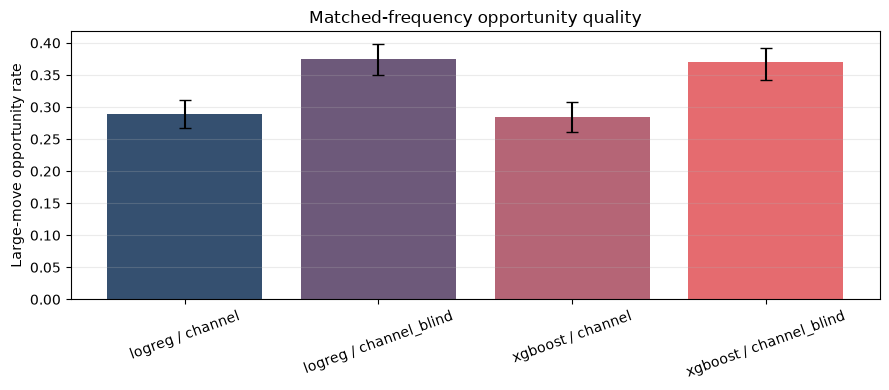

Method: Matched-frequency candidates are replayed under the same barrier and horizon contract.

,model,window_source,activations,opportunity_rate,opportunity_rate_ci_low,opportunity_rate_ci_high,mean_opportunity_score,direction_accuracy_on_resolved_hits,resolved_direction_rows,mean_barrier_bps,selected_inside_channel_fraction
0,logreg,channel,2939,0.2889,0.2667,0.3116,0.4232,0.5194,849,125.6067,1.0000
1,logreg,channel_blind,2939,0.3746,0.3507,0.3982,0.5103,0.5232,1101,133.4548,0.4406
2,xgboost,channel,2939,0.2851,0.2617,0.3086,0.4349,0.5274,838,125.4521,1.0000
3,xgboost,channel_blind,2939,0.3705,0.3429,0.3928,0.5005,0.5464,1089,131.8856,0.4410


Channel windows contain fewer resolved opportunities than the channel-blind control.

In [5]:
from IPython.display import Markdown
if READER_READY:
    table = FRAMES["opportunity_metrics.csv"].copy()
    labels = table["model"] + " / " + table["window_source"]
    y = table["opportunity_rate"].to_numpy(float)
    low = table["opportunity_rate_ci_low"].to_numpy(float)
    high = table["opportunity_rate_ci_high"].to_numpy(float)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(labels, y, color=["#355070", "#6d597a", "#b56576", "#e56b6f"])
    ax.errorbar(np.arange(len(y)), y, yerr=[y-low, high-y], fmt="none", color="black", capsize=4)
    ax.set_ylabel("Large-move opportunity rate")
    ax.set_title("Matched-frequency opportunity quality")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
    display(Markdown('Method: Matched-frequency candidates are replayed under the same barrier and horizon contract.'))
    display(table.round(4))
    display(Markdown('Channel windows contain fewer resolved opportunities than the channel-blind control.'))

## W5 — Economic result

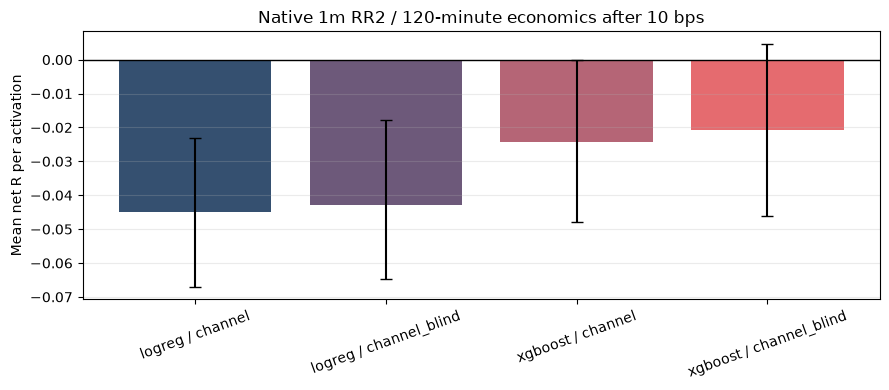

Method: Each arm/model keeps 2,939 activations and deducts the same 10 bps round-trip cost.

,model,window_source,activations,mean_gross_r,total_gross_r,mean_net_r,total_net_r,mean_net_r_ci_low,mean_net_r_ci_high,mean_net_bps,tp_fraction,sl_fraction,timeout_fraction,path_completeness
0,logreg,channel,2939,0.0377,110.8837,-0.0450,-132.1241,-0.0671,-0.0230,-4.9459,0.0269,0.1409,0.8323,1.0
1,logreg,channel_blind,2939,0.0355,104.2159,-0.0428,-125.7505,-0.0647,-0.0179,-5.5656,0.0347,0.1834,0.7819,1.0
2,xgboost,channel,2939,0.0582,171.0501,-0.0241,-70.9473,-0.0480,-0.0002,-2.4779,0.0289,0.1364,0.8346,1.0
3,xgboost,channel_blind,2939,0.0580,170.5497,-0.0207,-60.7374,-0.0461,0.0048,-2.1996,0.0401,0.1715,0.7884,1.0


All four realised mean Net R results are negative.

In [6]:
from IPython.display import Markdown
if READER_READY:
    table = FRAMES["economic_metrics.csv"].copy()
    labels = table["model"] + " / " + table["window_source"]
    y = table["mean_net_r"].to_numpy(float)
    low = table["mean_net_r_ci_low"].to_numpy(float)
    high = table["mean_net_r_ci_high"].to_numpy(float)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(labels, y, color=["#355070", "#6d597a", "#b56576", "#e56b6f"])
    ax.errorbar(np.arange(len(y)), y, yerr=[y-low, high-y], fmt="none", color="black", capsize=4)
    ax.axhline(0.0, color="black", linewidth=1)
    ax.set_ylabel("Mean net R per activation")
    ax.set_title("Native 1m RR2 / 120-minute economics after 10 bps")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
    display(Markdown('Method: Each arm/model keeps 2,939 activations and deducts the same 10 bps round-trip cost.'))
    display(table.round(4))
    display(Markdown('All four realised mean Net R results are negative.'))

## W6 — Stop rule

Channels are retained only if primary XGBoost has positive net R with its weekly-bootstrap lower bound above zero, and the channel-minus-blind lower bounds are above zero for both net R and opportunity rate. Otherwise we **close the channel branch** and write the dissertation from the evidence already obtained; LLM assistance remains a separate later question.

In [7]:
from IPython.display import Markdown
if READER_READY:
    display(Markdown('Method: Channel-minus-blind differences use 2,000 fixed calendar-week bootstrap resamples.'))
    display(FRAMES["matched_comparisons.csv"].round(4))
    display(Markdown('The economic intervals do not show a positive channel advantage.'))
    display(Markdown('Method: Counts and the global 60-minute refractory are verified without using outcome labels.'))
    display(FRAMES["frequency_audit.csv"].round(4))
    display(Markdown('Frequency is exactly matched across arms.'))
    display(Markdown('Method: Timestamp, feature, label and execution checks are evaluated against the registered contracts.'))
    display(FRAMES["leakage_audit.csv"])
    display(Markdown('The checks pass, but the economic gate fails and the channel branch closes.'))

Method: Channel-minus-blind differences use 2,000 fixed calendar-week bootstrap resamples.

,metric,model,candidate,baseline,point_delta,ci_low,ci_high,draws,bootstrap_unit
0,opportunity_rate,logreg,channel,channel_blind,-0.0857,-0.1035,-0.0674,2000,calendar_week
1,opportunity_rate,xgboost,channel,channel_blind,-0.0854,-0.1027,-0.0675,2000,calendar_week
2,mean_net_r,logreg,channel,channel_blind,-0.0022,-0.0245,0.0196,2000,calendar_week
3,mean_net_r,xgboost,channel,channel_blind,-0.0035,-0.0308,0.0218,2000,calendar_week


The economic intervals do not show a positive channel advantage.

Method: Counts and the global 60-minute refractory are verified without using outcome labels.

,model,window_source,activations,calendar_days,activations_per_day,fold_counts_exact,minimum_global_gap_minutes,global_60m_refractory_passed,matching_used_outcome_labels
0,logreg,channel,2939,1096,2.6816,True,60.0,True,False
1,logreg,channel_blind,2939,1096,2.6816,True,60.0,True,False
2,xgboost,channel,2939,1096,2.6816,True,60.0,True,False
3,xgboost,channel_blind,2939,1096,2.6816,True,60.0,True,False


Frequency is exactly matched across arms.

Method: Timestamp, feature, label and execution checks are evaluated against the registered contracts.

,check,passed,detail
0,development-only bounded raw reads,True,dd432770b6eb7fb6207f932fa754a440dc1236a9cbbdba...
1,frozen V foldwise activation counts,True,"{'2022H2': 236, '2023H1': 541, '2023H2': 305, ..."
2,shared models and OOF scores,True,one model/head/fold scored both candidate univ...
3,strict prior-label purge,True,120m label interval ends before validation
4,channel-free feature allow-list,True,20 opportunity + 17 direction
5,channel used only as candidate-universe restri...,True,in_channel_window excluded from both model mat...
6,exact matched frequency and global cooldown,True,2939 per arm/model; 2.681569/day
7,label-blind matched top-k,True,ranking uses only OOF opportunity_score and de...
8,native RR2/120m stop-first replay,True,both directions replayed at every selected nat...
9,uniform 5+5 costs,True,"10 bps on TP, SL and timeout"


The checks pass, but the economic gate fails and the channel branch closes.